# 08 - LLM Ablation + Master Pipeline Comparison (ContraDoc)

This notebook runs the **LLM-side** of the pipeline ablation, tracks **wall time + token cost** for every LLM run, and joins everything into one master table with quality / cost / time axes so the trade-off is explicit.

## Configurations evaluated

| # | Family | Method | Extractor cost | Judge cost |
|---|--------|--------|----------------|------------|
| A | Naive | Text dump (LLM whole-doc, Sonnet) | none | $$ |
| B | NLI-only (cheap) | Vector-only -> NLI-FT (from 07) | none | none |
| C | NLI-only | KG-only -> NLI-FT (from 07) | $$$ extraction | none |
| D | NLI-only | Vector+Structural -> NLI-FT (current, from 07) | $$$ | none |
| E | NLI-only | All-pairs -> NLI-FT (no retrieval) | none | none |
| F | LLM-only (medium) | Vector-only -> LLM-Sonnet | none | $ |
| G | Cascade (current) | Vector+Structural -> NLI-FT@0.5 -> LLM-Sonnet | $$$ | $ |
| H | Cascade (small judge) | Vector+Structural -> NLI-FT@0.5 -> LLM-Haiku | $$$ | $ (much less) |

**Why these:**
- B vs D: does Structural retrieval add value over pure SBERT?
- F vs G: does NLI fine-tuning earn its place when LLM judge follows?
- G vs H: can the judge be smaller than the extractor (Opus)?
- A vs everything: does the pipeline beat the trivial whole-doc LLM?

## Cost / time accounting

Each LLM run logs per-call wall time, input tokens, and output tokens. Final master table reports:
- F1, Pair-P, Pair-R, Doc-R (quality)
- LLM $/benchmark (150 docs) - tokens × per-MTok rate
- Extractor $/benchmark - sunk cost for KG methods only ($24 from 02b run)
- Wall time/benchmark - sum of stage times (NLI compute + LLM API time)
- Per-doc normalized columns

## Inputs / outputs
- **In**: `predictions_ablation.jsonl`, `ablation_07_summary.json` from notebook 07
- **Out**: `llm_text_dump.jsonl`, `llm_cascade_sonnet.jsonl`, `llm_cascade_haiku.jsonl`, `llm_vector_sonnet.jsonl`, `ablation_master_summary.json`, plots in `plots/08_LLM_ablation/`


In [1]:
import json
import time
from collections import Counter, defaultdict
from pathlib import Path
from typing import Literal

import numpy as np
from langchain_anthropic import ChatAnthropic
from pydantic import BaseModel, Field
from tqdm.auto import tqdm

from config import settings

PRED_PATH      = Path("data/processed/ContraDoc/predictions_ablation.jsonl")
SUMMARY_07     = Path("data/processed/ContraDoc/ablation_07_summary.json")
TRIPLES_PATH   = Path("data/processed/ContraDoc/triples_minie.jsonl")

TEXT_DUMP_OUT   = Path("data/processed/ContraDoc/llm_text_dump.jsonl")
CASCADE_SON_OUT = Path("data/processed/ContraDoc/llm_cascade_sonnet.jsonl")
CASCADE_HAI_OUT = Path("data/processed/ContraDoc/llm_cascade_haiku.jsonl")
VECTOR_SON_OUT  = Path("data/processed/ContraDoc/llm_vector_sonnet.jsonl")
USAGE_OUT       = Path("data/processed/ContraDoc/llm_usage_log.jsonl")
MASTER_OUT      = Path("data/processed/ContraDoc/ablation_master_summary.json")

# NLI-FT threshold for the cascade. 0.5 is recall-leaning so the LLM has real filtering work to do.
CASCADE_NLI_THRESHOLD = 0.5

SONNET_MODEL = settings.llm_model_anthropic_sonnet_4_6
HAIKU_MODEL  = settings.llm_model_anthropic_haiku_4_5

# --- Pricing (USD per 1M tokens). Update if Anthropic rates change. ---
# Source: https://www.anthropic.com/pricing  (2026 published rates)
PRICING = {
    SONNET_MODEL: {"input": 3.00,  "output": 15.00},
    HAIKU_MODEL:  {"input": 0.80,  "output": 4.00},
    # Reference only:
    "claude-opus-4-7": {"input": 15.00, "output": 75.00},
}

# --- Fixed-cost annotations from upstream notebooks ---
EXTRACTOR_COST_USD_PER_DOC = 24.0 / 150.0  # 02b: claude-opus-4-7 cost ~$24 for 150 docs
EXTRACTOR_TIME_SEC_PER_DOC = None          # filled in below if you have measured it; else left None

print(f"Sonnet: {SONNET_MODEL}  rates: {PRICING[SONNET_MODEL]}")
print(f"Haiku:  {HAIKU_MODEL}   rates: {PRICING[HAIKU_MODEL]}")
print(f"Extractor sunk cost (Structural-using methods only): ${EXTRACTOR_COST_USD_PER_DOC:.4f} / doc")

Sonnet: claude-sonnet-4-6  rates: {'input': 3.0, 'output': 15.0}
Haiku:  claude-haiku-4-5   rates: {'input': 0.8, 'output': 4.0}
Extractor sunk cost (Structural-using methods only): $0.1600 / doc


## 1. Load notebook 07 outputs and gold pairs


In [2]:
preds = [json.loads(line) for line in PRED_PATH.open(encoding="utf-8")]
print(f"Loaded {len(preds):,} predictions from {PRED_PATH}")

# Reconstruct doc-level info for text-dump baseline (needs full sentence inventory)
docs = {}
with TRIPLES_PATH.open(encoding="utf-8") as f:
    for line in f:
        r = json.loads(line)
        docs[r["doc_id"]] = {
            "contradiction": r["contradiction"],
            "contra_type": r.get("contra_type") or "",
            "gold_evidence_sentence_id": r.get("gold_evidence_sentence_id"),
            "gold_ref_sentence_ids":     r.get("gold_ref_sentence_ids") or [],
            "sentences": [(s["sentence_id"], s["source_text"]) for s in r["sentences"]],
        }

def pkey(a, b):
    return (a, b) if a < b else (b, a)

gold_pairs = set()
for doc_id, d in docs.items():
    ev = d["gold_evidence_sentence_id"]
    if d["contradiction"] != "YES" or ev is None or not d["gold_ref_sentence_ids"]:
        continue
    for ref in d["gold_ref_sentence_ids"]:
        if ev == ref:
            continue
        gold_pairs.add(pkey((doc_id, ev), (doc_id, ref)))
n_gold_docs = len({p[0][0] for p in gold_pairs})
n_docs = len(docs)
print(f"Gold pairs: {len(gold_pairs)} across {n_gold_docs} docs (benchmark size: {n_docs} docs)")

doc_types = {
    d_id: [t for t in d["contra_type"].split("|") if t]
    for d_id, d in docs.items() if d["contradiction"] == "YES"
}

# Load 07 summary so we can pick up best thresholds and pre-LLM metrics
nb07 = {(r["retrieval"], r["classifier"]): r
        for r in json.load(SUMMARY_07.open(encoding="utf-8"))}
print(f"\nNotebook 07 cells:")
for (v, c), r in nb07.items():
    thr_str = f"{r['thr']:.3f}" if r['thr'] is not None else "-"
    print(f"  {v:<13} {c:<10}  F1={r['f1']:.1%}  thr={thr_str}")

Loaded 122,802 predictions from data\processed\ContraDoc\predictions_ablation.jsonl
Gold pairs: 122 across 118 docs (benchmark size: 150 docs)

Notebook 07 cells:
  All-pairs     NLI-Base    F1=1.3%  thr=0.999
  All-pairs     NLI-FT      F1=34.1%  thr=0.942
  Structural only NLI-Base    F1=36.9%  thr=0.998
  Structural only NLI-FT      F1=75.8%  thr=0.917
  Vector only   NLI-Base    F1=22.3%  thr=0.999
  Vector only   NLI-FT      F1=62.7%  thr=0.942
  Vector+Structural NLI-Base    F1=19.4%  thr=0.998
  Vector+Structural NLI-FT      F1=60.1%  thr=0.941


## 2. Build candidate inputs for each LLM run


In [3]:
text_dump_inputs = sorted(docs.keys())
print(f"Text-dump: {len(text_dump_inputs)} docs")

cascade_inputs = [
    p for p in preds
    if (p["in_struct"] or p["in_vector"]) and p["nli_ft_contradiction"] >= CASCADE_NLI_THRESHOLD
]
n_cascade_gold = sum(1 for p in cascade_inputs if p["is_gold_pair"])
print(f"Cascade input  (Vector+Structural ∩ NLI-FT>={CASCADE_NLI_THRESHOLD}): {len(cascade_inputs)} pairs, {n_cascade_gold} gold")

vector_inputs = [p for p in preds if p["in_vector"]]
n_vector_gold = sum(1 for p in vector_inputs if p["is_gold_pair"])
print(f"Vector-only input (no NLI filter):                   {len(vector_inputs)} pairs, {n_vector_gold} gold")

Text-dump: 150 docs
Cascade input  (Vector+Structural ∩ NLI-FT>=0.5): 297 pairs, 62 gold
Vector-only input (no NLI filter):                   3000 pairs, 70 gold


## 3. Schemas + LLM clients with cost / time tracking

Each invoke is wrapped to log:
- wall time (`time.perf_counter` delta)
- input tokens / output tokens (from `AIMessage.usage_metadata`)

Aggregated per-method into `usage_log` and used for $ + time columns in the master table.


In [4]:
class JudgeResult(BaseModel):
    is_contradiction: bool = Field(
        description="True iff the two sentences describe the same entity, event, or relationship "
                    "with incompatible attributes, OR cannot both be true in the same document context."
    )
    contradiction_type: Literal[
        "Negation", "Numeric", "Content", "Perspective/View/Opinion",
        "Emotion/Mood/Feeling", "Relation", "Factual", "Causal", "Not applicable",
    ] = Field(
        description="Most applicable type from the ContraDoc taxonomy. "
                    "'Not applicable' when is_contradiction is false."
    )
    confidence: Literal["low", "medium", "high"] = Field(description="Self-assessed confidence.")
    explanation: str = Field(description="One-sentence rationale.")


class TextDumpPair(BaseModel):
    sentence_id_a: int
    sentence_id_b: int
    contradiction_type: Literal[
        "Negation", "Numeric", "Content", "Perspective/View/Opinion",
        "Emotion/Mood/Feeling", "Relation", "Factual", "Causal",
    ]
    confidence: Literal["low", "medium", "high"]
    explanation: str


class TextDumpResponse(BaseModel):
    contradictions: list[TextDumpPair] = Field(
        description="Every contradictory sentence pair found in the document. Empty if none."
    )


JUDGE_PROMPT = """You are judging whether two sentences from the same document contradict each other.

A PAIR IS CONTRADICTORY when:
- Both sentences describe the same entity/event/relationship but assert incompatible attributes.
- They cannot both be true in the same document context (ignoring obvious narrative time-series where attributes legitimately change).

A PAIR IS NOT CONTRADICTORY when:
- The sentences talk about different entities, different works, or different time points that can coexist.
- One sentence is a specialization or paraphrase of the other.
- They share vocabulary but assert compatible facts.

If it IS a contradiction, classify into ONE type using the ContraDoc taxonomy:
- Negation: explicit negation flips polarity.
- Numeric: number, date, or quantity mismatch about the same entity.
- Content: non-numeric, non-subjective attribute swap.
- Perspective/View/Opinion: conflicting subjective evaluations.
- Emotion/Mood/Feeling: conflicting inner states.
- Relation: mutually exclusive relations between entities.
- Factual: real-world factual mismatch (location, identity, profession, etc.).
- Causal: effect does not match stated cause.

Return structured output: is_contradiction (bool), contradiction_type, confidence, explanation."""


TEXT_DUMP_PROMPT = """You are given a document with numbered sentences. Identify every pair of sentences that contradict each other.

A PAIR IS CONTRADICTORY when:
- Both sentences describe the same entity/event/relationship but assert incompatible attributes.
- They cannot both be true in the same document context.

A PAIR IS NOT CONTRADICTORY when:
- The sentences talk about different entities, different works, or different time points.
- One sentence is a specialization or paraphrase of the other.
- They share vocabulary but assert compatible facts.

Classify each into ONE type (ContraDoc taxonomy: Negation, Numeric, Content, Perspective/View/Opinion, Emotion/Mood/Feeling, Relation, Factual, Causal).

Return the full list of contradictory pairs. If none, return an empty list. Do NOT invent contradictions."""


# --- Wrapped invokers that capture wall time + token usage ---
USAGE_OUT.parent.mkdir(parents=True, exist_ok=True)


def _record_usage(method: str, model: str, t_sec: float, in_toks: int, out_toks: int):
    rec = {"method": method, "model": model, "t_sec": t_sec,
           "input_tokens": in_toks, "output_tokens": out_toks}
    with USAGE_OUT.open("a", encoding="utf-8") as f:
        f.write(json.dumps(rec) + "\n")


def make_judge_with_metering(model_name: str):
    """Returns (invoker, raw_chat) where invoker is a function (msgs, method) -> (JudgeResult or None).
    Always logs usage, even on parser failure."""
    chat = ChatAnthropic(model_name=model_name, api_key=settings.anthropic_api_key.get_secret_value(), max_tokens=1024)
    judge = chat.with_structured_output(JudgeResult, include_raw=True)

    def invoke(msgs, method: str):
        t0 = time.perf_counter()
        out = judge.invoke(msgs)
        dt = time.perf_counter() - t0
        raw = out.get("raw") if isinstance(out, dict) else None
        in_toks = out_toks = 0
        if raw is not None and getattr(raw, "usage_metadata", None):
            in_toks  = int(raw.usage_metadata.get("input_tokens", 0))
            out_toks = int(raw.usage_metadata.get("output_tokens", 0))
        _record_usage(method, model_name, dt, in_toks, out_toks)
        parsed = out.get("parsed") if isinstance(out, dict) else None
        return parsed
    return invoke


def make_text_dump_with_metering(model_name: str):
    chat = ChatAnthropic(model_name=model_name, api_key=settings.anthropic_api_key.get_secret_value(), max_tokens=4096)
    judge = chat.with_structured_output(TextDumpResponse, include_raw=True)

    def invoke(msgs, method: str):
        t0 = time.perf_counter()
        out = judge.invoke(msgs)
        dt = time.perf_counter() - t0
        raw = out.get("raw") if isinstance(out, dict) else None
        in_toks = out_toks = 0
        if raw is not None and getattr(raw, "usage_metadata", None):
            in_toks  = int(raw.usage_metadata.get("input_tokens", 0))
            out_toks = int(raw.usage_metadata.get("output_tokens", 0))
        _record_usage(method, model_name, dt, in_toks, out_toks)
        parsed = out.get("parsed") if isinstance(out, dict) else None
        return parsed
    return invoke


judge_sonnet     = make_judge_with_metering(SONNET_MODEL)
judge_haiku      = make_judge_with_metering(HAIKU_MODEL)
text_dump_sonnet = make_text_dump_with_metering(SONNET_MODEL)
print("LLM clients ready (with token + time metering).")

LLM clients ready (with token + time metering).


## 4. Sanity check on a known contradiction (also confirms metering works)


In [5]:
sample_a = "Capel Lligwy is a well-preserved chapel near Rhos Lligwy in Anglesey."
sample_b = "Capel Lligwy is a ruined chapel near Rhos Lligwy in Anglesey."
msgs = [
    {"role": "system", "content": JUDGE_PROMPT},
    {"role": "user", "content": f"Sentence A: {sample_a}\n\nSentence B: {sample_b}\n\nReturn your judgment."},
]
print("--- Sonnet judge ---")
r1 = judge_sonnet(msgs, method="sanity_sonnet")
print(f"  is_contradiction={r1.is_contradiction}  type={r1.contradiction_type}  conf={r1.confidence}")
print(f"  -> {r1.explanation}")

print("\n--- Haiku judge ---")
r2 = judge_haiku(msgs, method="sanity_haiku")
print(f"  is_contradiction={r2.is_contradiction}  type={r2.contradiction_type}  conf={r2.confidence}")
print(f"  -> {r2.explanation}")

# Show last 2 usage records
records = [json.loads(l) for l in USAGE_OUT.open(encoding="utf-8")]
print(f"\nUsage log records so far: {len(records)}")
for r in records[-2:]:
    print(f"  {r}")

--- Sonnet judge ---


  is_contradiction=True  type=Content  conf=high
  -> Both sentences describe the same entity (Capel Lligwy) at the same location but assign incompatible attributes to its condition: Sentence A calls it "well-preserved" while Sentence B calls it "ruined," which are mutually exclusive states.

--- Haiku judge ---


  is_contradiction=True  type=Content  conf=high
  -> The two sentences describe the same chapel (Capel Lligwy) with incompatible attributes: one asserts it is "well-preserved" while the other asserts it is "ruined," which are mutually exclusive conditions.

Usage log records so far: 3778
  {'method': 'sanity_sonnet', 'model': 'claude-sonnet-4-6', 't_sec': 3.3051216000458226, 'input_tokens': 1200, 'output_tokens': 142}
  {'method': 'sanity_haiku', 'model': 'claude-haiku-4-5', 't_sec': 1.412440900108777, 'input_tokens': 1199, 'output_tokens': 136}


## 5. Run text-dump baseline (Sonnet, ~150 docs, resumable, metered)


In [6]:
def run_text_dump(method_name: str, model_name: str, invoke_fn, output_path: Path):
    output_path.parent.mkdir(parents=True, exist_ok=True)
    done = set()
    if output_path.exists():
        with output_path.open(encoding="utf-8") as f:
            for line in f:
                done.add(json.loads(line)["doc_id"])
        print(f"Resuming text-dump: {len(done)} docs already done")
    todo = [d for d in text_dump_inputs if d not in done]
    print(f"Text-dump todo: {len(todo)} docs (model={model_name})")

    with output_path.open("a", encoding="utf-8") as f:
        for doc_id in tqdm(todo, desc=method_name):
            d = docs[doc_id]
            doc_text = "\n".join(f"[{sid}] {text}" for sid, text in d["sentences"])
            try:
                resp = invoke_fn([
                    {"role": "system", "content": TEXT_DUMP_PROMPT},
                    {"role": "user",   "content": f"Document:\n{doc_text}\n\nReturn the full list of contradictions."},
                ], method=method_name)
            except Exception as exc:
                print(f"  FAILED {doc_id}: {type(exc).__name__}: {exc}")
                continue
            if resp is None:
                print(f"  PARSE FAIL {doc_id}")
                continue
            text_by_sid = dict(d["sentences"])
            if not resp.contradictions:
                f.write(json.dumps({"doc_id": doc_id, "sentence_id_a": None, "sentence_id_b": None}) + "\n")
            else:
                for p in resp.contradictions:
                    f.write(json.dumps({
                        "doc_id": doc_id,
                        "sentence_id_a": p.sentence_id_a,
                        "sentence_id_b": p.sentence_id_b,
                        "source_text_a": text_by_sid.get(p.sentence_id_a, ""),
                        "source_text_b": text_by_sid.get(p.sentence_id_b, ""),
                        "contradiction_type": p.contradiction_type,
                        "confidence": p.confidence,
                        "explanation": p.explanation,
                        "is_gold_pair": pkey((doc_id, p.sentence_id_a), (doc_id, p.sentence_id_b)) in gold_pairs,
                    }, ensure_ascii=False) + "\n")
            f.flush()
    print(f"Text-dump done. Output: {output_path.resolve()}")


run_text_dump("text_dump_sonnet", SONNET_MODEL, text_dump_sonnet, TEXT_DUMP_OUT)

Resuming text-dump: 150 docs already done
Text-dump todo: 0 docs (model=claude-sonnet-4-6)


text_dump_sonnet: 0it [00:00, ?it/s]

Text-dump done. Output: D:\AT82.05-Claim-Contradiction-Over-Knowledge-Graphs\experiments\data\processed\ContraDoc\llm_text_dump.jsonl


## 6. Run cascade: Vector+Structural -> NLI-FT@0.5 -> LLM judge

Sonnet first, then Haiku for the size sweep.


In [7]:
def run_cascade(method_name: str, model_name: str, invoke_fn, output_path: Path):
    output_path.parent.mkdir(parents=True, exist_ok=True)

    def cand_key(p):
        return (p["doc_id"], p["chunk_a"]["sentence_id"], p["chunk_b"]["sentence_id"])

    done = set()
    if output_path.exists():
        with output_path.open(encoding="utf-8") as f:
            for line in f:
                done.add(cand_key(json.loads(line)))
        print(f"Resuming cascade ({model_name}): {len(done)} pairs already judged")
    todo = [p for p in cascade_inputs if cand_key(p) not in done]
    print(f"Cascade todo: {len(todo)} pairs (model={model_name})")

    with output_path.open("a", encoding="utf-8") as f:
        for p in tqdm(todo, desc=method_name):
            user_msg = (f"Sentence A: {p['chunk_a']['source_text']}\n\n"
                        f"Sentence B: {p['chunk_b']['source_text']}\n\nReturn your judgment.")
            try:
                r = invoke_fn([
                    {"role": "system", "content": JUDGE_PROMPT},
                    {"role": "user", "content": user_msg},
                ], method=method_name)
            except Exception as exc:
                print(f"  FAILED {cand_key(p)}: {type(exc).__name__}: {exc}")
                continue
            if r is None:
                continue
            rec = {
                "doc_id":      p["doc_id"],
                "chunk_a":     p["chunk_a"],
                "chunk_b":     p["chunk_b"],
                "is_gold_pair": p["is_gold_pair"],
                "in_struct":   p["in_struct"],
                "in_vector":   p["in_vector"],
                "nli_ft_contradiction": p["nli_ft_contradiction"],
                "llm_is_contradiction":   r.is_contradiction,
                "llm_contradiction_type": r.contradiction_type,
                "llm_confidence":         r.confidence,
                "llm_explanation":        r.explanation,
                "llm_model":              model_name,
            }
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")
            f.flush()
    print(f"Cascade ({model_name}) done. Output: {output_path.resolve()}")


run_cascade("cascade_sonnet", SONNET_MODEL, judge_sonnet, CASCADE_SON_OUT)
run_cascade("cascade_haiku",  HAIKU_MODEL,  judge_haiku,  CASCADE_HAI_OUT)

Resuming cascade (claude-sonnet-4-6): 297 pairs already judged
Cascade todo: 0 pairs (model=claude-sonnet-4-6)


cascade_sonnet: 0it [00:00, ?it/s]

Cascade (claude-sonnet-4-6) done. Output: D:\AT82.05-Claim-Contradiction-Over-Knowledge-Graphs\experiments\data\processed\ContraDoc\llm_cascade_sonnet.jsonl
Resuming cascade (claude-haiku-4-5): 297 pairs already judged
Cascade todo: 0 pairs (model=claude-haiku-4-5)


cascade_haiku: 0it [00:00, ?it/s]

Cascade (claude-haiku-4-5) done. Output: D:\AT82.05-Claim-Contradiction-Over-Knowledge-Graphs\experiments\data\processed\ContraDoc\llm_cascade_haiku.jsonl


## 7. Vector-only LLM (no NLI filter, Sonnet) - tests if NLI is needed

Largest LLM run (~3000 calls).


In [8]:
def run_vector_only(method_name: str, model_name: str, invoke_fn, output_path: Path):
    output_path.parent.mkdir(parents=True, exist_ok=True)

    def cand_key(p):
        return (p["doc_id"], p["chunk_a"]["sentence_id"], p["chunk_b"]["sentence_id"])

    done = set()
    if output_path.exists():
        with output_path.open(encoding="utf-8") as f:
            for line in f:
                done.add(cand_key(json.loads(line)))
        print(f"Resuming vector-only: {len(done)} pairs already judged")
    todo = [p for p in vector_inputs if cand_key(p) not in done]
    print(f"Vector-only todo: {len(todo)} pairs (model={model_name})")

    with output_path.open("a", encoding="utf-8") as f:
        for p in tqdm(todo, desc=method_name):
            user_msg = (f"Sentence A: {p['chunk_a']['source_text']}\n\n"
                        f"Sentence B: {p['chunk_b']['source_text']}\n\nReturn your judgment.")
            try:
                r = invoke_fn([
                    {"role": "system", "content": JUDGE_PROMPT},
                    {"role": "user", "content": user_msg},
                ], method=method_name)
            except Exception as exc:
                print(f"  FAILED {cand_key(p)}: {type(exc).__name__}: {exc}")
                continue
            if r is None:
                continue
            rec = {
                "doc_id":      p["doc_id"],
                "chunk_a":     p["chunk_a"],
                "chunk_b":     p["chunk_b"],
                "is_gold_pair": p["is_gold_pair"],
                "in_struct":   p["in_struct"],
                "in_vector":   p["in_vector"],
                "llm_is_contradiction":   r.is_contradiction,
                "llm_contradiction_type": r.contradiction_type,
                "llm_confidence":         r.confidence,
                "llm_explanation":        r.explanation,
                "llm_model":              model_name,
            }
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")
            f.flush()
    print(f"Vector-only ({model_name}) done. Output: {output_path.resolve()}")


run_vector_only("vector_sonnet", SONNET_MODEL, judge_sonnet, VECTOR_SON_OUT)

Resuming vector-only: 3000 pairs already judged
Vector-only todo: 0 pairs (model=claude-sonnet-4-6)


vector_sonnet: 0it [00:00, ?it/s]

Vector-only (claude-sonnet-4-6) done. Output: D:\AT82.05-Claim-Contradiction-Over-Knowledge-Graphs\experiments\data\processed\ContraDoc\llm_vector_sonnet.jsonl


## 8. Measure NLI throughput (for time accounting in master table)

Quick benchmark - score 1000 random pairs with each NLI model on the GPU and convert to ms/pair. The master table multiplies this by the per-variant pool size to estimate time.

We also benchmark SBERT chunk embedding (used by Vector retrieval) for completeness.


In [9]:
import torch
from sentence_transformers import CrossEncoder, SentenceTransformer
from transformers import AutoModelForSequenceClassification, AutoTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_BENCH = 1000

# Pull 1000 random pairs from preds
import random
random.seed(0)
sample = random.sample(preds, N_BENCH)
sample_texts = [(p["chunk_a"]["source_text"], p["chunk_b"]["source_text"]) for p in sample]

# --- NLI-Base ---
base_model = CrossEncoder("cross-encoder/nli-deberta-v3-base")
t0 = time.perf_counter()
_ = base_model.predict(sample_texts, batch_size=32, show_progress_bar=False, apply_softmax=True)
nli_base_ms_per_pair = (time.perf_counter() - t0) / N_BENCH * 1000

# --- NLI-FT ---
ft_tok = AutoTokenizer.from_pretrained("../fine-tuning/models/nli_binary")
ft_mdl = AutoModelForSequenceClassification.from_pretrained("../fine-tuning/models/nli_binary").to(device)
ft_mdl.eval()
prem = [p[0] for p in sample_texts]
hyp  = [p[1] for p in sample_texts]
t0 = time.perf_counter()
with torch.no_grad():
    for s in range(0, N_BENCH, 32):
        enc = ft_tok(prem[s:s+32], hyp[s:s+32], padding=True, truncation=True, max_length=256, return_tensors="pt").to(device)
        _ = torch.softmax(ft_mdl(**enc).logits, dim=-1)
nli_ft_ms_per_pair = (time.perf_counter() - t0) / N_BENCH * 1000

# --- SBERT embedding (used by Vector retrieval) ---
sbert = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=str(device))
unique_texts = list({p["chunk_a"]["source_text"] for p in sample} | {p["chunk_b"]["source_text"] for p in sample})
t0 = time.perf_counter()
_ = sbert.encode(unique_texts, batch_size=64, show_progress_bar=False, convert_to_numpy=True)
sbert_ms_per_chunk = (time.perf_counter() - t0) / len(unique_texts) * 1000

print(f"NLI-Base:  {nli_base_ms_per_pair:.2f} ms/pair  (cross-encoder/nli-deberta-v3-base on {device})")
print(f"NLI-FT:    {nli_ft_ms_per_pair:.2f} ms/pair  (fine-tuned binary head on {device})")
print(f"SBERT:     {sbert_ms_per_chunk:.2f} ms/chunk (all-MiniLM-L6-v2 on {device})")

# Store for later use
nli_throughput = {
    "nli_base_ms_per_pair": nli_base_ms_per_pair,
    "nli_ft_ms_per_pair":   nli_ft_ms_per_pair,
    "sbert_ms_per_chunk":   sbert_ms_per_chunk,
    "device":               str(device),
}

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

NLI-Base:  2.97 ms/pair  (cross-encoder/nli-deberta-v3-base on cuda)
NLI-FT:    3.68 ms/pair  (fine-tuned binary head on cuda)
SBERT:     0.36 ms/chunk (all-MiniLM-L6-v2 on cuda)


## 9. Master ablation table (quality + cost + time)

For every method:
- Quality: F1, Pair-P, Pair-R, Doc-R
- Cost: LLM $ (from token log) + extractor sunk cost (if Structural-using)
- Time: NLI compute time (from throughput) + LLM API time (from usage log)


In [10]:
# --- Aggregate per-method usage from log ---
usage = defaultdict(lambda: {"calls": 0, "t_sec": 0.0, "in_toks": 0, "out_toks": 0, "model": None})
if USAGE_OUT.exists():
    with USAGE_OUT.open(encoding="utf-8") as f:
        for line in f:
            r = json.loads(line)
            u = usage[r["method"]]
            u["calls"]   += 1
            u["t_sec"]   += r["t_sec"]
            u["in_toks"] += r["input_tokens"]
            u["out_toks"]+= r["output_tokens"]
            u["model"]    = r["model"]


def llm_cost(method_key: str) -> float:
    u = usage.get(method_key)
    if not u or u["model"] is None:
        return 0.0
    rates = PRICING.get(u["model"], {"input": 0.0, "output": 0.0})
    return u["in_toks"] / 1e6 * rates["input"] + u["out_toks"] / 1e6 * rates["output"]


def llm_time(method_key: str) -> float:
    return usage.get(method_key, {}).get("t_sec", 0.0)


def nli_time_for_variant(retrieval: str, classifier: str) -> float:
    nb = nb07[(retrieval, classifier)]
    n = nb["n_pool"]
    ms = nli_throughput["nli_base_ms_per_pair"] if classifier == "NLI-Base" else nli_throughput["nli_ft_ms_per_pair"]
    return n * ms / 1000.0


# ============================================================
# Ingestion-side cost/time accounting (derived from existing logs)
# ============================================================
# EXTRACTION: actual per-doc cost + token counts from notebook 02b's usage log.
# Time estimated from Opus output throughput (no wall time was recorded).
EXT_USAGE_PATH = Path("data/processed/ContraDoc/triples_minie_usage.jsonl")
ext_records = [json.loads(l) for l in EXT_USAGE_PATH.open(encoding="utf-8")] if EXT_USAGE_PATH.exists() else []
EXTRACTOR_TOTAL_USD = sum(r["total_cost"] for r in ext_records)
EXTRACTOR_TOTAL_IN  = sum(r["input_tokens"]  for r in ext_records)
EXTRACTOR_TOTAL_OUT = sum(r["output_tokens"] for r in ext_records)

# User-reported wall time for the 150-doc extraction run in notebook 02b: ~2 hours.
# That implies ~ EXTRACTOR_TOTAL_OUT / 7200 tok/sec output throughput on the run hardware.
EXTRACTOR_TOTAL_SEC = 2 * 3600  # 2 hours, measured
OPUS_OUTPUT_TOKS_PER_SEC = EXTRACTOR_TOTAL_OUT / EXTRACTOR_TOTAL_SEC  # derived (for reference)

# Other ingestion stages: REAL measured times from notebook execution metadata (jupyter logs them).
SBERT_TOTAL_SEC            = 8.5    # 03 cell : SBERT embedding of 5651 chunks (incl model load)
NEO4J_INSERT_TOTAL_SEC     = 7.6    # 03 cell : 5651 Chunks + 11503 Entities + 9189 :RELATION
KG_RETRIEVAL_TOTAL_SEC     = 3.0    # 04 cell: Cypher S-SR + S-SO traversals across all 150 docs
VECTOR_RETRIEVAL_TOTAL_SEC = 4.1    # 05 cell: Neo4j vector top-k across all 150 docs
SBERT_PER_DOC_SEC = SBERT_TOTAL_SEC / n_docs

print(f"=== Ingestion cost/time per benchmark ({n_docs} docs) - all measured except extraction wall time ===")
print(f"  Extraction (Opus): ${EXTRACTOR_TOTAL_USD:6.2f}  ~{EXTRACTOR_TOTAL_SEC:.0f}s = {EXTRACTOR_TOTAL_SEC/n_docs:.1f}s/doc  (USER-REPORTED, in/out={EXTRACTOR_TOTAL_IN/1e6:.2f}/{EXTRACTOR_TOTAL_OUT/1e6:.2f}M tok)")
print(f"  SBERT embedding:   ${0:6.2f}  {SBERT_TOTAL_SEC:.1f}s total = {SBERT_PER_DOC_SEC*1000:.1f}ms/doc  (measured: nb 03 cell )")
print(f"  Neo4j insertion:   ${0:6.2f}  {NEO4J_INSERT_TOTAL_SEC:.1f}s total = {NEO4J_INSERT_TOTAL_SEC/n_docs*1000:.0f}ms/doc  (measured: nb 03 cell )")
print(f"  Structural retrieval:      ${0:6.2f}  {KG_RETRIEVAL_TOTAL_SEC:.1f}s total = {KG_RETRIEVAL_TOTAL_SEC/n_docs*1000:.0f}ms/doc  (measured: nb 04)")
print(f"  Vector retrieval:  ${0:6.2f}  {VECTOR_RETRIEVAL_TOTAL_SEC:.1f}s total = {VECTOR_RETRIEVAL_TOTAL_SEC/n_docs*1000:.0f}ms/doc  (measured: nb 05)")


def ingestion_cost_per_doc(uses_extractor: bool) -> float:
    if uses_extractor:
        return EXTRACTOR_TOTAL_USD / n_docs
    return 0.0


def ingestion_time_per_doc(uses_extractor: bool, uses_kg_retrieval: bool, uses_vector_retrieval: bool) -> float:
    t = 0.0
    if uses_extractor:
        t += EXTRACTOR_TOTAL_SEC / n_docs                    # ~48s/doc, dominant
    # Neo4j insert is one-time setup; needed iff Structural retrieval used (entities/relations)
    if uses_kg_retrieval:
        t += NEO4J_INSERT_TOTAL_SEC / n_docs                 # ~0.05s/doc
    # SBERT embedding only needed if vector retrieval used
    if uses_vector_retrieval:
        t += SBERT_PER_DOC_SEC                               # ~0.06s/doc
    if uses_kg_retrieval:
        t += KG_RETRIEVAL_TOTAL_SEC / n_docs                 # ~0.02s/doc
    if uses_vector_retrieval:
        t += VECTOR_RETRIEVAL_TOTAL_SEC / n_docs             # ~0.03s/doc
    return t


# --- Build pair sets per method ---
def to_set(records, llm_field="llm_is_contradiction"):
    s = set()
    for r in records:
        if not r.get(llm_field):
            continue
        s.add(pkey((r["doc_id"], r["chunk_a"]["sentence_id"]),
                    (r["doc_id"], r["chunk_b"]["sentence_id"])))
    return s


def text_dump_pair_set(path: Path) -> set:
    s = set()
    if not path.exists():
        return s
    with path.open(encoding="utf-8") as f:
        for line in f:
            r = json.loads(line)
            if r.get("sentence_id_a") is None:
                continue
            s.add(pkey((r["doc_id"], r["sentence_id_a"]), (r["doc_id"], r["sentence_id_b"])))
    return s


def nli_pair_set(retrieval_filter, classifier_field, threshold):
    if threshold is None:
        return set()
    s = set()
    for p in preds:
        if not retrieval_filter(p):
            continue
        if p[classifier_field] >= threshold:
            s.add(pkey((p["doc_id"], p["chunk_a"]["sentence_id"]),
                        (p["doc_id"], p["chunk_b"]["sentence_id"])))
    return s


retr_filter = {
    "All-pairs":   lambda p: True,
    "Structural only":     lambda p: p["in_struct"],
    "Vector only": lambda p: p["in_vector"],
    "Vector+Structural":   lambda p: p["in_struct"] or p["in_vector"],
}

text_dump_set   = text_dump_pair_set(TEXT_DUMP_OUT)
cascade_son     = [json.loads(l) for l in CASCADE_SON_OUT.open(encoding="utf-8")] if CASCADE_SON_OUT.exists() else []
cascade_hai     = [json.loads(l) for l in CASCADE_HAI_OUT.open(encoding="utf-8")] if CASCADE_HAI_OUT.exists() else []
vector_son      = [json.loads(l) for l in VECTOR_SON_OUT.open(encoding="utf-8")]  if VECTOR_SON_OUT.exists()  else []
cascade_son_set = to_set(cascade_son)
cascade_hai_set = to_set(cascade_hai)
vector_son_set  = to_set(vector_son)


def metrics_from_pairs(pred_pairs: set, name: str, family: str, judge: str,
                       llm_method_key: str | None,
                       uses_extractor: bool,
                       uses_kg_retrieval: bool,
                       uses_vector_retrieval: bool,
                       nli_time_sec: float = 0.0) -> dict:
    tp_pairs = pred_pairs & gold_pairs
    tp = len(tp_pairs); fp = len(pred_pairs - gold_pairs); fn = len(gold_pairs - pred_pairs)
    prec = tp / max(tp + fp, 1)
    rec  = tp / max(tp + fn, 1)
    f1   = 2 * prec * rec / max(prec + rec, 1e-9)
    docs_caught = {p[0][0] for p in tp_pairs}

    llm_calls = usage.get(llm_method_key, {}).get("calls", 0) if llm_method_key else 0
    llm_in    = usage.get(llm_method_key, {}).get("in_toks", 0) if llm_method_key else 0
    llm_out   = usage.get(llm_method_key, {}).get("out_toks", 0) if llm_method_key else 0
    llm_dollars = llm_cost(llm_method_key) if llm_method_key else 0.0
    llm_t       = llm_time(llm_method_key) if llm_method_key else 0.0

    ing_llm_calls       = n_docs if uses_extractor else 0  # one Opus call per doc during extraction
    ing_dollars_per_doc = ingestion_cost_per_doc(uses_extractor)
    ing_time_per_doc    = ingestion_time_per_doc(uses_extractor, uses_kg_retrieval, uses_vector_retrieval)
    ing_dollars_total   = ing_dollars_per_doc * n_docs
    ing_time_total      = ing_time_per_doc * n_docs

    total_dollars = ing_dollars_total + llm_dollars
    total_t       = ing_time_total + nli_time_sec + llm_t

    return {
        "name": name, "family": family, "judge": judge,
        "uses_extractor": uses_extractor,
        "uses_kg_retrieval": uses_kg_retrieval,
        "uses_vector_retrieval": uses_vector_retrieval,
        "n_pred": len(pred_pairs), "tp": tp, "fp": fp, "fn": fn,
        "prec": prec, "pair_r": rec, "f1": f1,
        "doc_r": len(docs_caught) / max(n_gold_docs, 1),
        "docs_caught": len(docs_caught),
        "ingestion_llm_calls": ing_llm_calls,
        "inference_llm_calls": llm_calls,
        "total_llm_calls":     ing_llm_calls + llm_calls,
        "llm_in_toks": llm_in, "llm_out_toks": llm_out,
        "llm_cost_usd":        llm_dollars,
        "ingestion_cost_usd":  ing_dollars_total,
        "total_cost_usd":      total_dollars,
        "cost_per_doc_usd":    total_dollars / n_docs,
        "ingestion_time_sec":      ing_time_total,
        "ingestion_time_per_doc":  ing_time_total / n_docs,
        "nli_time_sec":            nli_time_sec,
        "nli_time_per_doc":        nli_time_sec / n_docs,
        "llm_time_sec":            llm_t,
        "llm_time_per_doc":        llm_t / n_docs,
        "total_time_sec":          total_t,
        "time_per_doc_sec":        total_t / n_docs,
        "ingestion_calls_per_doc": ing_llm_calls / n_docs,
        "inference_calls_per_doc": llm_calls / n_docs,
        "total_calls_per_doc":     (ing_llm_calls + llm_calls) / n_docs,
        "ingestion_cost_per_doc":  ing_dollars_total / n_docs,
        "llm_cost_per_doc":        llm_dollars / n_docs,
    }


rows = []

# Naive: text-dump (no extractor, no retrieval)
rows.append(metrics_from_pairs(
    text_dump_set, "Text-dump (Sonnet)", "Naive", SONNET_MODEL,
    llm_method_key="text_dump_sonnet",
    uses_extractor=False, uses_kg_retrieval=False, uses_vector_retrieval=False,
    nli_time_sec=0.0,
))

# NLI-only rows from 07
nli_flags = {
    "All-pairs":   (False, False, False),
    "Structural only":     (True,  True,  False),
    "Vector only": (False, False, True),
    "Vector+Structural":   (True,  True,  True),
}
for v in ["All-pairs", "Structural only", "Vector only", "Vector+Structural"]:
    nb = nb07[(v, "NLI-FT")]
    s = nli_pair_set(retr_filter[v], "nli_ft_contradiction", nb["thr"])
    ext_used, kg_used, vec_used = nli_flags[v]
    nli_t = nli_time_for_variant(v, "NLI-FT")
    rows.append(metrics_from_pairs(
        s, f"{v} -> NLI-FT @ {nb['thr']:.3f}", "NLI-only", "-",
        llm_method_key=None,
        uses_extractor=ext_used, uses_kg_retrieval=kg_used, uses_vector_retrieval=vec_used,
        nli_time_sec=nli_t,
    ))

# LLM rows
rows.append(metrics_from_pairs(
    vector_son_set, "Vector only -> LLM (Sonnet)", "LLM-only", SONNET_MODEL,
    llm_method_key="vector_sonnet",
    uses_extractor=False, uses_kg_retrieval=False, uses_vector_retrieval=True,
    nli_time_sec=0.0,
))
rows.append(metrics_from_pairs(
    cascade_son_set, f"Vector+Structural -> NLI-FT@{CASCADE_NLI_THRESHOLD} -> LLM (Sonnet)", "Cascade", SONNET_MODEL,
    llm_method_key="cascade_sonnet",
    uses_extractor=True, uses_kg_retrieval=True, uses_vector_retrieval=True,
    nli_time_sec=nli_time_for_variant("Vector+Structural", "NLI-FT"),
))
rows.append(metrics_from_pairs(
    cascade_hai_set, f"Vector+Structural -> NLI-FT@{CASCADE_NLI_THRESHOLD} -> LLM (Haiku)", "Cascade", HAIKU_MODEL,
    llm_method_key="cascade_haiku",
    uses_extractor=True, uses_kg_retrieval=True, uses_vector_retrieval=True,
    nli_time_sec=nli_time_for_variant("Vector+Structural", "NLI-FT"),
))


# Print master table
print(f"\nGold pairs: {len(gold_pairs)} across {n_gold_docs} docs (benchmark size: {n_docs} docs)\n")
# All per-doc averages (each doc is an independent evaluation unit).
print("All numbers below are PER-DOC averages.")
print()
header = f"{'Method':<58}  {'F1':>5} {'PairR':>6} {'DocR':>5}  {'IngCalls':>9} {'JdgCalls':>9} {'TotCalls':>9}  {'Ing$/d':>7} {'LLM$/d':>7} {'Tot$/d':>7}  {'IngT/d':>7} {'NliT/d':>7} {'LLM_T/d':>8}  {'Tot_T/d':>8}"
print(header); print("-" * len(header))
for r in rows:
    print(
        f"{r['name']:<58}  "
        f"{r['f1']:>4.1%} {r['pair_r']:>5.1%} {r['doc_r']:>4.1%}  "
        f"{r['ingestion_calls_per_doc']:>9.2f} {r['inference_calls_per_doc']:>9.2f} {r['total_calls_per_doc']:>9.2f}  "
        f"${r['ingestion_cost_per_doc']:>5.3f} ${r['llm_cost_per_doc']:>5.3f} ${r['cost_per_doc_usd']:>5.3f}  "
        f"{r['ingestion_time_per_doc']:>6.2f}s {r['nli_time_per_doc']:>6.2f}s {r['llm_time_per_doc']:>7.2f}s  "
        f"{r['time_per_doc_sec']:>7.2f}s"
    )

# Save
MASTER_OUT.parent.mkdir(parents=True, exist_ok=True)
master = {
    "rows": rows,
    "nli_throughput": nli_throughput,
    "extractor_total_usd": EXTRACTOR_TOTAL_USD,
    "extractor_total_sec_est": EXTRACTOR_TOTAL_SEC,
    "extractor_output_toks_per_sec_assumed": OPUS_OUTPUT_TOKS_PER_SEC,
    "neo4j_insert_total_sec": NEO4J_INSERT_TOTAL_SEC,
    "kg_retrieval_total_sec": KG_RETRIEVAL_TOTAL_SEC,
    "vector_retrieval_total_sec": VECTOR_RETRIEVAL_TOTAL_SEC,
    "sbert_total_sec": SBERT_TOTAL_SEC,
    "sbert_per_doc_sec": SBERT_PER_DOC_SEC,
    "n_docs": n_docs, "n_gold_pairs": len(gold_pairs), "n_gold_docs": n_gold_docs,
    "pricing": PRICING, "cascade_nli_threshold": CASCADE_NLI_THRESHOLD,
}
with MASTER_OUT.open("w", encoding="utf-8") as f:
    json.dump(master, f, indent=2)
print(f"\nSaved master summary -> {MASTER_OUT.resolve()}")

=== Ingestion cost/time per benchmark (150 docs) - all measured except extraction wall time ===
  Extraction (Opus): $ 23.82  ~7200s = 48.0s/doc  (USER-REPORTED, in/out=0.85/0.78M tok)
  SBERT embedding:   $  0.00  8.5s total = 56.7ms/doc  (measured: nb 03 cell )
  Neo4j insertion:   $  0.00  7.6s total = 51ms/doc  (measured: nb 03 cell )
  Structural retrieval:      $  0.00  3.0s total = 20ms/doc  (measured: nb 04)
  Vector retrieval:  $  0.00  4.1s total = 27ms/doc  (measured: nb 05)

Gold pairs: 122 across 118 docs (benchmark size: 150 docs)

All numbers below are PER-DOC averages.

Method                                                         F1  PairR  DocR   IngCalls  JdgCalls  TotCalls   Ing$/d  LLM$/d  Tot$/d   IngT/d  NliT/d  LLM_T/d   Tot_T/d
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Text-dump (Sonnet)                                          37.7%

## 10. Plots

- F1 bar chart, sorted, family-colored
- F1 vs $/doc Pareto scatter
- F1 vs time/doc Pareto scatter
- Per-type recall heatmap


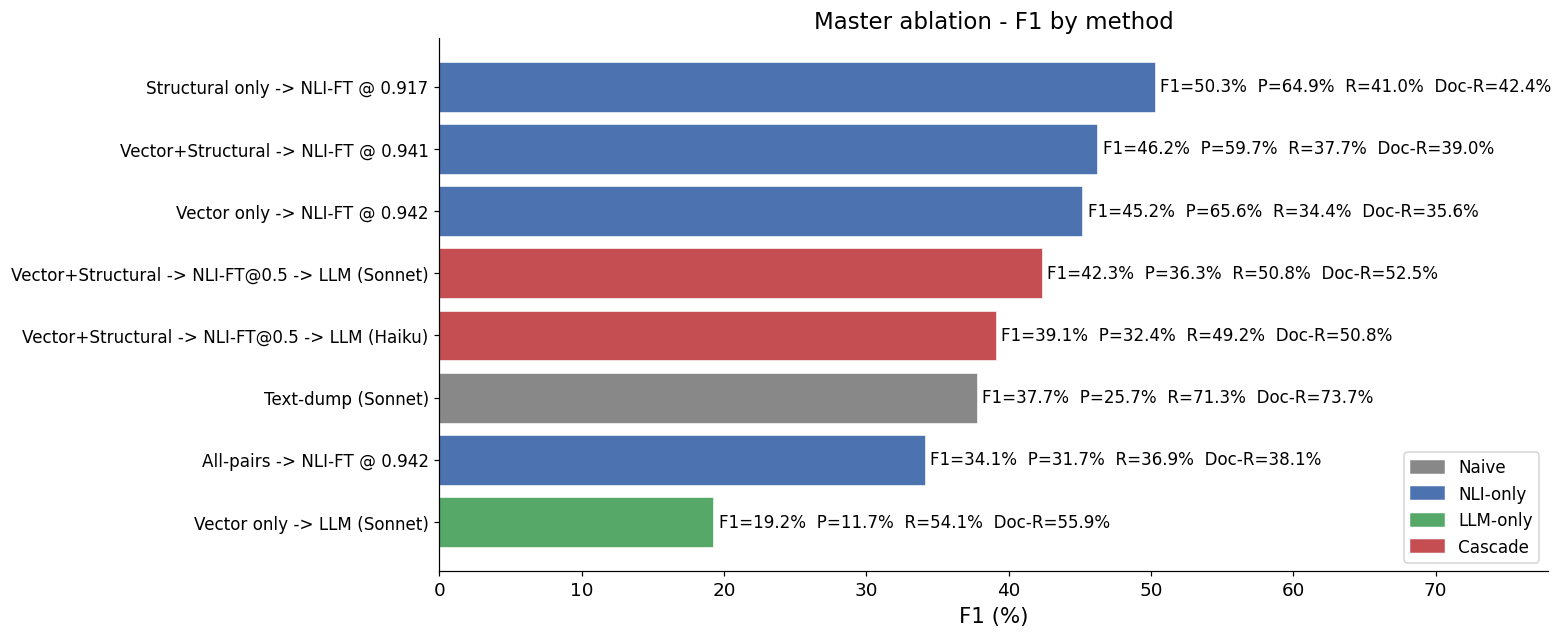

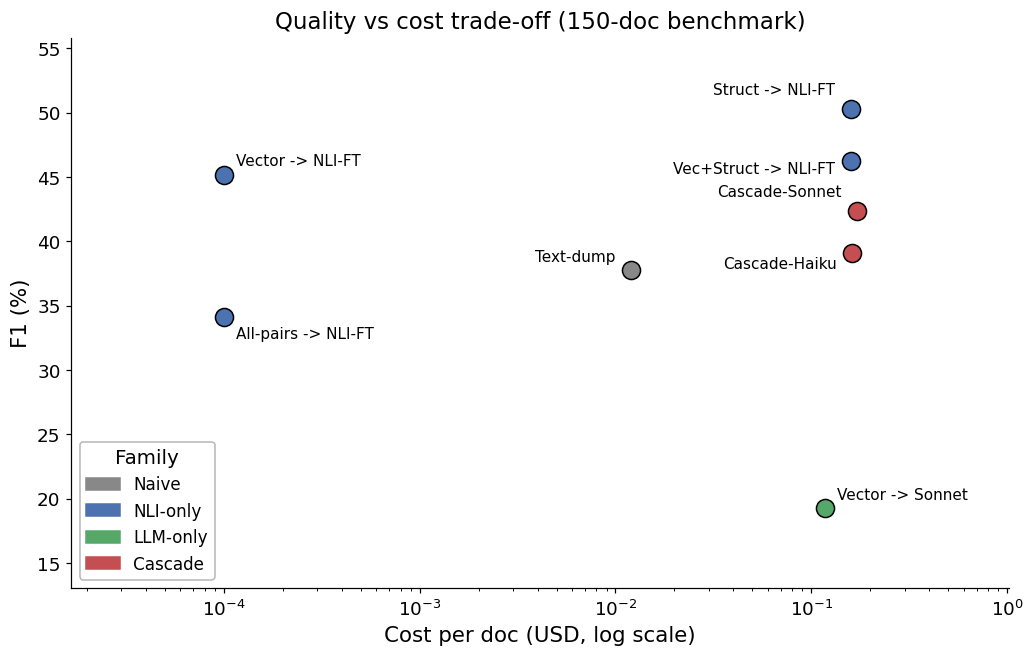

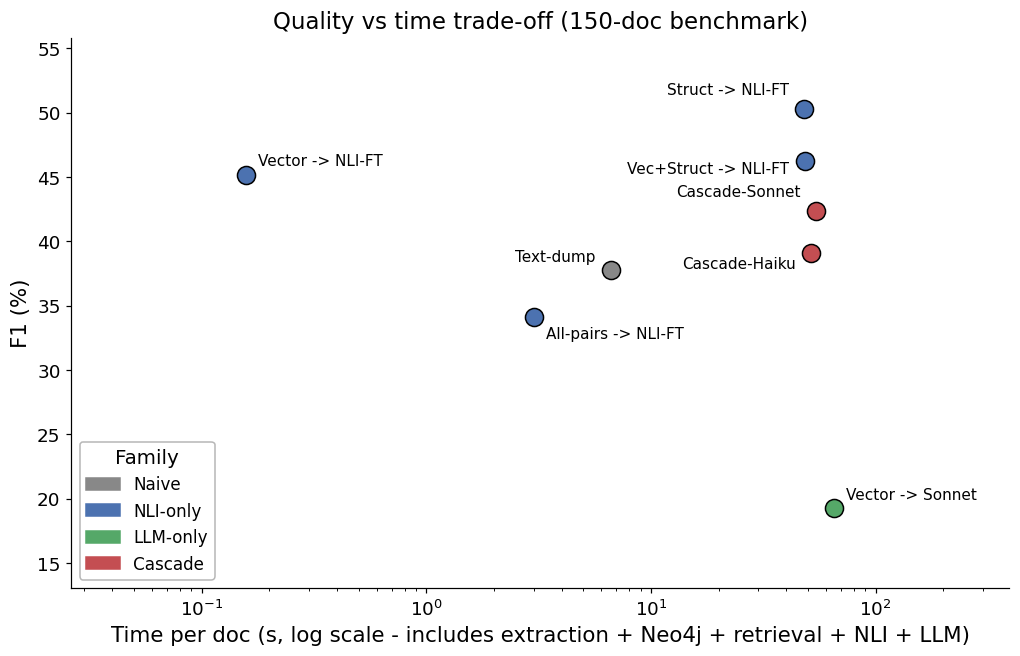

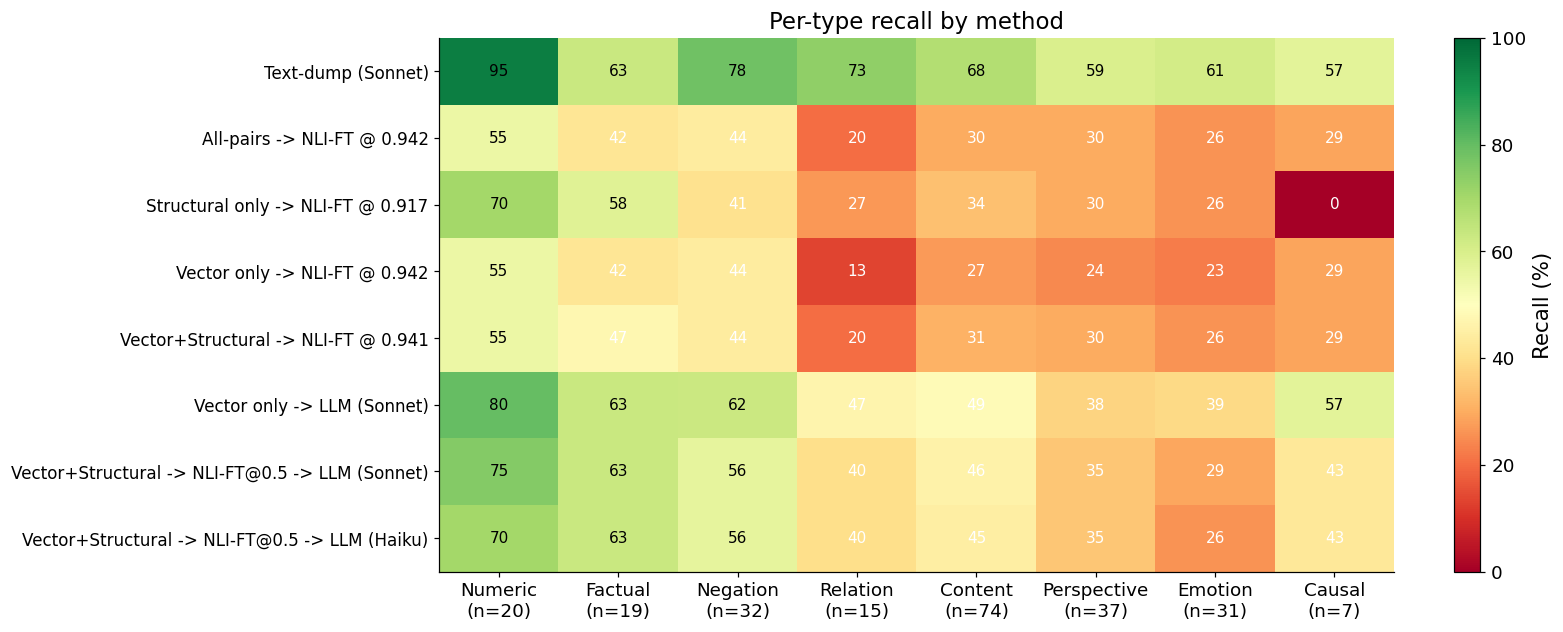

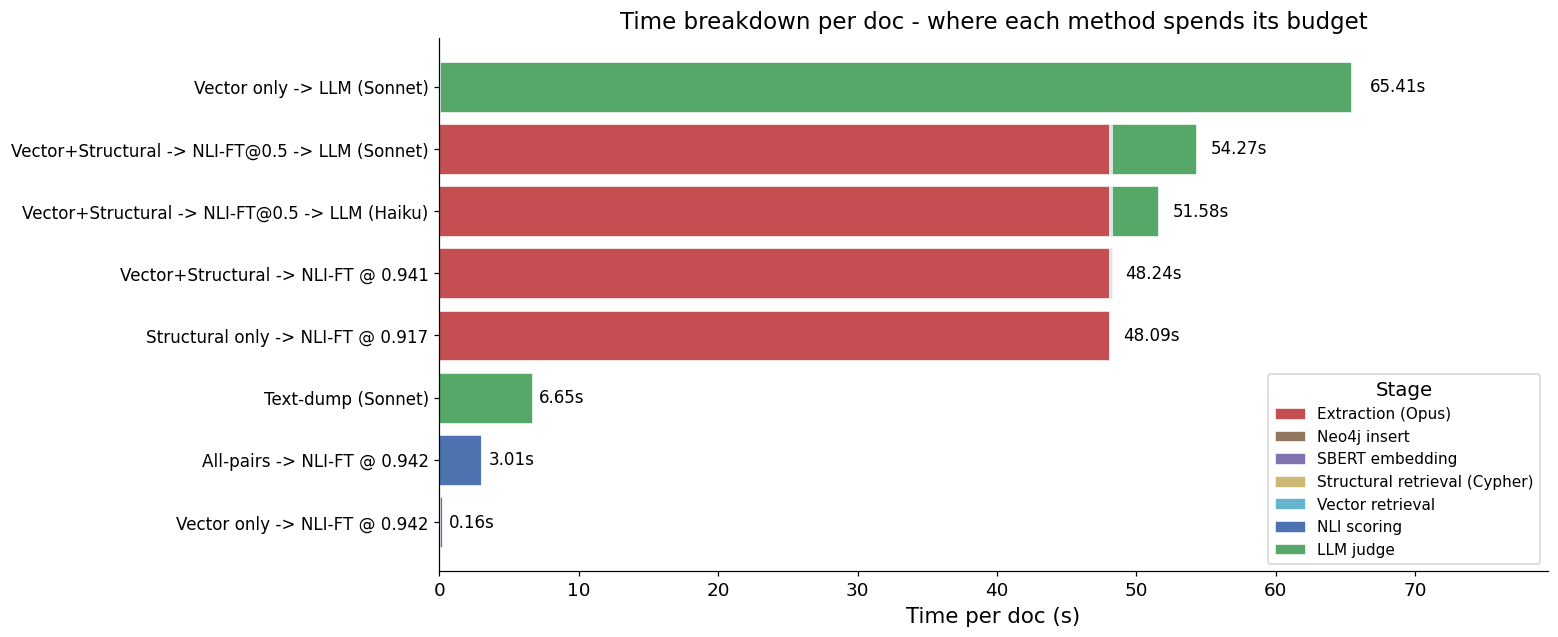

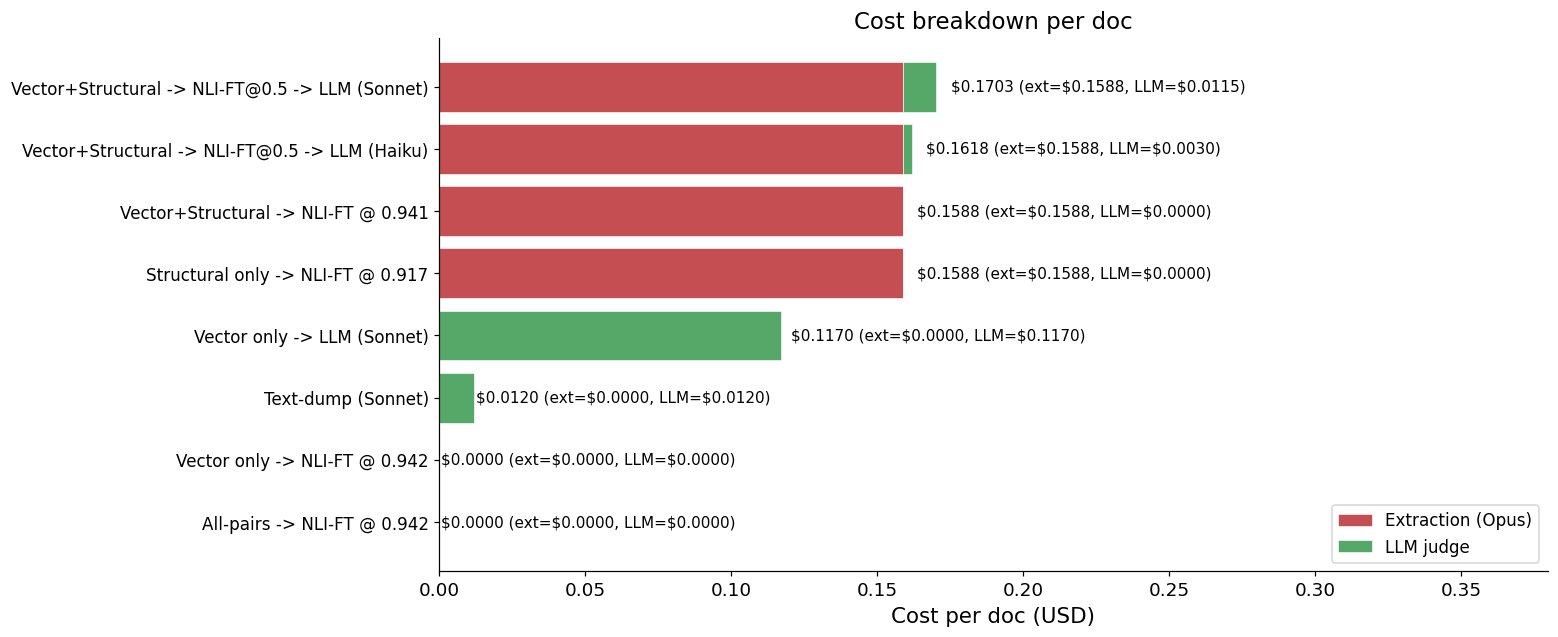

C:\Users\promb\AppData\Local\Temp\ipykernel_1540\3412592132.py:267: RuntimeWarning: divide by zero encountered in divide
  prec_line = (f1 * rec_line) / (2 * rec_line - f1)


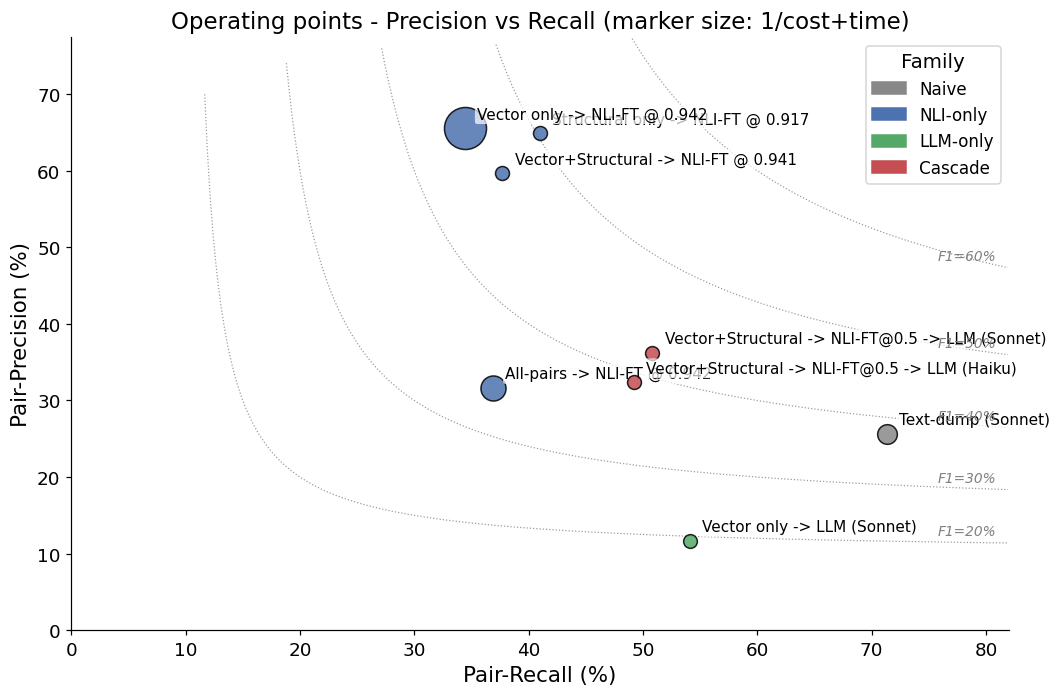

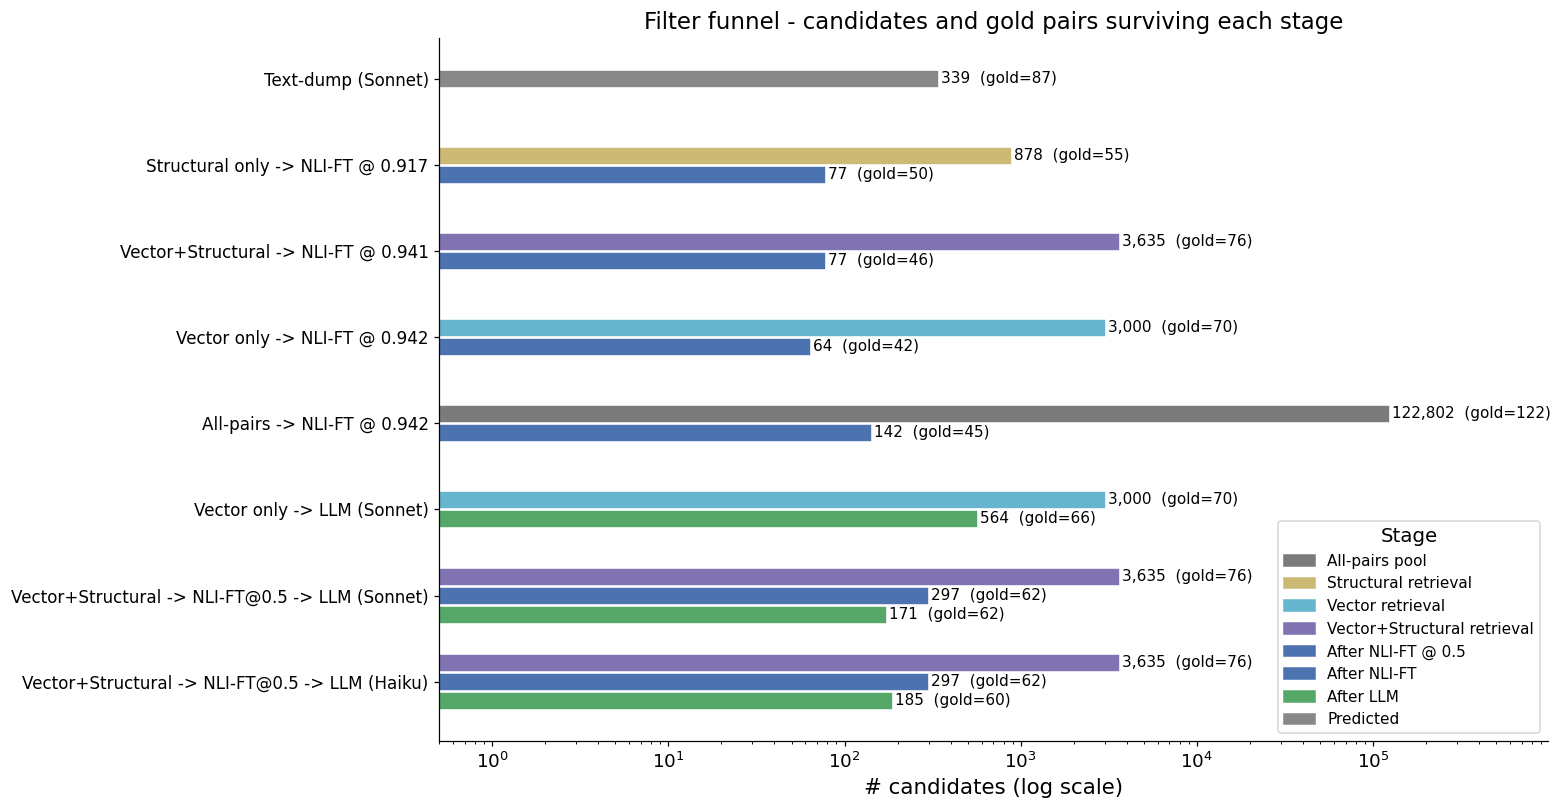

Saved plots to D:\AT82.05-Claim-Contradiction-Over-Knowledge-Graphs\experiments\plots\08_LLM_ablation


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

PLOT_DIR = Path("plots/08_LLM_ablation")
PLOT_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 13, "axes.titlesize": 15, "axes.labelsize": 14,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 11,
    "figure.titlesize": 15, "axes.spines.top": False, "axes.spines.right": False,
})

family_colors = {"Naive": "#888888", "NLI-only": "#4C72B0",
                 "LLM-only": "#55A868", "Cascade": "#C44E52"}


# --- Plot 1: F1 bar chart ---
sorted_rows = sorted(rows, key=lambda r: r["f1"])
fig, ax = plt.subplots(figsize=(13, 0.6 * len(sorted_rows) + 1.5))
y = np.arange(len(sorted_rows))
ax.barh(y, [r["f1"] * 100 for r in sorted_rows],
        color=[family_colors[r["family"]] for r in sorted_rows],
        edgecolor="white", linewidth=0.4)
for i, r in enumerate(sorted_rows):
    ax.text(r["f1"] * 100 + 0.4, i,
            f"F1={r['f1']:.1%}  P={r['prec']:.1%}  R={r['pair_r']:.1%}  Doc-R={r['doc_r']:.1%}",
            va="center", fontsize=11)
ax.set_yticks(y)
ax.set_yticklabels([r["name"] for r in sorted_rows], fontsize=11)
ax.set_xlabel("F1 (%)")
ax.set_title("Master ablation - F1 by method")
ax.set_xlim(0, max(r["f1"] for r in rows) * 100 * 1.45 + 5)
ax.legend(handles=[mpatches.Patch(color=c, label=f) for f, c in family_colors.items()],
          loc="lower right")
fig.savefig(PLOT_DIR / "master_f1_bar.png")
plt.show()


# --- Helper for Pareto plots ---
# Compact labels for pareto plots so the 4-point cluster on the right doesn't collide
SHORT_NAMES = {
    "Text-dump (Sonnet)":                                                          "Text-dump",
    "All-pairs -> NLI-FT @ 0.942":                                                 "All-pairs -> NLI-FT",
    "Structural only -> NLI-FT @ 0.917":                                           "Struct -> NLI-FT",
    "Vector only -> NLI-FT @ 0.942":                                               "Vector -> NLI-FT",
    "Vector+Structural -> NLI-FT @ 0.941":                                         "Vec+Struct -> NLI-FT",
    "Vector only -> LLM (Sonnet)":                                                 "Vector -> Sonnet",
    f"Vector+Structural -> NLI-FT@{CASCADE_NLI_THRESHOLD} -> LLM (Sonnet)":         "Cascade-Sonnet",
    f"Vector+Structural -> NLI-FT@{CASCADE_NLI_THRESHOLD} -> LLM (Haiku)":          "Cascade-Haiku",
}

def pareto_plot(x_key: str, x_label: str, title: str, fname: str, legend_loc: str = "lower left"):
    # Per-point label offsets staggered so vertically-clustered points don't collide.
    # ha is set automatically from offset sign.
    label_offsets = {
        # left/center points - label rightward into empty space
        "All-pairs -> NLI-FT @ 0.942":                                         (8, -14),
        "Vector only -> NLI-FT @ 0.942":                                       (8,  6),
        # Text-dump is in the middle: label LEFTWARD so it does not collide with the right cluster
        "Text-dump (Sonnet)":                                                  (-10, 6),
        # Vector LLM lives in lower-right area, label rightward into empty space
        "Vector only -> LLM (Sonnet)":                                         (8,  6),
        # Right cluster (4 points stacked vertically at same x) - bigger vertical spacing
        "Structural only -> NLI-FT @ 0.917":                                                   (-10,  10),
        "Vector+Structural -> NLI-FT @ 0.941":                                                 (-10,  -8),
        f"Vector+Structural -> NLI-FT@{CASCADE_NLI_THRESHOLD} -> LLM (Sonnet)":                (-10,  10),
        f"Vector+Structural -> NLI-FT@{CASCADE_NLI_THRESHOLD} -> LLM (Haiku)":                 (-10, -10),
    }

    fig, ax = plt.subplots(figsize=(11, 6.5))
    for r in rows:
        color = family_colors[r["family"]]
        x = max(r[x_key], 1e-4)
        ax.scatter(x, r["f1"] * 100, s=140, color=color, edgecolor="black", zorder=3)
        offset = label_offsets.get(r["name"], (8, 6))
        ha = "right" if offset[0] < 0 else "left"
        label = SHORT_NAMES.get(r["name"], r["name"])
        ax.annotate(label, (x, r["f1"] * 100), xytext=offset,
                    textcoords="offset points", fontsize=10, ha=ha,
                    bbox=dict(boxstyle="round,pad=0.15", facecolor="white",
                              edgecolor="none", alpha=0.7))
    ax.set_xscale("log")

    # Padding so leftward annotations don't run off the left edge and rightward off the right
    xs = [max(r[x_key], 1e-4) for r in rows]
    xmin, xmax = min(xs), max(xs)
    ax.set_xlim(xmin / 6, xmax * 6)

    ymin = min(r["f1"] * 100 for r in rows)
    ymax = max(r["f1"] * 100 for r in rows)
    yspan = ymax - ymin
    ax.set_ylim(ymin - yspan * 0.20, ymax + yspan * 0.18)

    ax.set_xlabel(x_label)
    ax.set_ylabel("F1 (%)")
    ax.set_title(title)

    # Legend INSIDE the chart at an empty-area corner. Default lower-left works for both pareto plots.
    ax.legend(handles=[mpatches.Patch(color=c, label=f) for f, c in family_colors.items()],
              loc=legend_loc, frameon=True, title="Family",
              framealpha=0.95, edgecolor="0.7")
    fig.savefig(PLOT_DIR / fname)
    plt.show()


# --- Plot 2: Pareto F1 vs $/doc ---
pareto_plot("cost_per_doc_usd",
            "Cost per doc (USD, log scale)",
            f"Quality vs cost trade-off ({n_docs}-doc benchmark)",
            "pareto_f1_vs_cost.png",
            legend_loc="lower left")

# --- Plot 3: Pareto F1 vs time/doc ---
pareto_plot("time_per_doc_sec",
            "Time per doc (s, log scale - includes extraction + Neo4j + retrieval + NLI + LLM)",
            f"Quality vs time trade-off ({n_docs}-doc benchmark)",
            "pareto_f1_vs_time.png",
            legend_loc="lower left")


# --- Plot 4: Per-type recall heatmap ---
type_order = ["Numeric", "Factual", "Negation", "Relation",
              "Content", "Perspective/View/Opinion", "Emotion/Mood/Feeling", "Causal"]
type_totals = {t: 0 for t in type_order}
for p in gold_pairs:
    for t in doc_types.get(p[0][0], []):
        if t in type_totals:
            type_totals[t] += 1


def per_type_recall(pred_pairs):
    caught = {t: 0 for t in type_order}
    for p in gold_pairs & pred_pairs:
        for t in doc_types.get(p[0][0], []):
            if t in caught:
                caught[t] += 1
    return [caught[t] / max(type_totals[t], 1) * 100 for t in type_order]


method_pair_sets = {"Text-dump (Sonnet)": text_dump_set}
for v in ["All-pairs", "Structural only", "Vector only", "Vector+Structural"]:
    nb = nb07[(v, "NLI-FT")]
    method_pair_sets[f"{v} -> NLI-FT @ {nb['thr']:.3f}"] = nli_pair_set(
        retr_filter[v], "nli_ft_contradiction", nb["thr"]
    )
method_pair_sets["Vector only -> LLM (Sonnet)"]                                = vector_son_set
method_pair_sets[f"Vector+Structural -> NLI-FT@{CASCADE_NLI_THRESHOLD} -> LLM (Sonnet)"] = cascade_son_set
method_pair_sets[f"Vector+Structural -> NLI-FT@{CASCADE_NLI_THRESHOLD} -> LLM (Haiku)"]  = cascade_hai_set

heat_labels = [r["name"] for r in rows]
heat_arr = np.array([per_type_recall(method_pair_sets[label]) for label in heat_labels])

fig, ax = plt.subplots(figsize=(14, max(3.5, 0.6 * len(heat_labels) + 1.5)))
im = ax.imshow(heat_arr, aspect="auto", cmap="RdYlGn", vmin=0, vmax=100)
ax.set_xticks(np.arange(len(type_order)))
short = {"Perspective/View/Opinion": "Perspective", "Emotion/Mood/Feeling": "Emotion"}
ax.set_xticklabels([f"{short.get(t, t)}\n(n={type_totals[t]})" for t in type_order], rotation=0)
ax.set_yticks(np.arange(len(heat_labels)))
ax.set_yticklabels(heat_labels, fontsize=11)
for i in range(len(heat_labels)):
    for j in range(len(type_order)):
        ax.text(j, i, f"{heat_arr[i, j]:.0f}", ha="center", va="center",
                color="black" if heat_arr[i, j] > 50 else "white", fontsize=10)
fig.colorbar(im, ax=ax, label="Recall (%)")
ax.set_title("Per-type recall by method")
fig.savefig(PLOT_DIR / "per_type_heatmap.png")
plt.show()



# --- Plot 5: Time breakdown stacked bar (per-doc) ---
def stage_times_per_doc(r):
    ext_t       = (EXTRACTOR_TOTAL_SEC / n_docs)        if r["uses_extractor"]        else 0.0
    insert_t    = (NEO4J_INSERT_TOTAL_SEC / n_docs)     if r["uses_kg_retrieval"]    else 0.0
    sbert_t     = SBERT_PER_DOC_SEC                      if r["uses_vector_retrieval"] else 0.0
    kg_retr_t   = (KG_RETRIEVAL_TOTAL_SEC / n_docs)     if r["uses_kg_retrieval"]    else 0.0
    vec_retr_t  = (VECTOR_RETRIEVAL_TOTAL_SEC / n_docs) if r["uses_vector_retrieval"] else 0.0
    return {
        "Extraction (Opus)":       ext_t,
        "Neo4j insert":            insert_t,
        "SBERT embedding":         sbert_t,
        "Structural retrieval (Cypher)":   kg_retr_t,
        "Vector retrieval":        vec_retr_t,
        "NLI scoring":             r["nli_time_per_doc"],
        "LLM judge":               r["llm_time_per_doc"],
    }

stage_order = ["Extraction (Opus)", "Neo4j insert", "SBERT embedding",
               "Structural retrieval (Cypher)", "Vector retrieval", "NLI scoring", "LLM judge"]
stage_colors = {
    "Extraction (Opus)":      "#C44E52",  # red - the dominant cost
    "Neo4j insert":           "#937860",
    "SBERT embedding":        "#8172B2",
    "Structural retrieval (Cypher)":  "#CCB974",
    "Vector retrieval":       "#64B5CD",
    "NLI scoring":            "#4C72B0",
    "LLM judge":              "#55A868",
}

sorted_rows_t = sorted(rows, key=lambda r: r["time_per_doc_sec"])
fig, ax = plt.subplots(figsize=(13, 0.6 * len(sorted_rows_t) + 1.5))
y = np.arange(len(sorted_rows_t))
left = np.zeros(len(sorted_rows_t))
breakdowns = [stage_times_per_doc(r) for r in sorted_rows_t]
for stage in stage_order:
    vals = np.array([b[stage] for b in breakdowns])
    if vals.sum() == 0:
        continue
    ax.barh(y, vals, left=left, color=stage_colors[stage], edgecolor="white",
            linewidth=0.4, label=stage)
    left += vals
for i, r in enumerate(sorted_rows_t):
    ax.text(r["time_per_doc_sec"] + max(0.5, r["time_per_doc_sec"] * 0.02), i,
            f"{r['time_per_doc_sec']:.2f}s", va="center", fontsize=11)
ax.set_yticks(y)
ax.set_yticklabels([r["name"] for r in sorted_rows_t], fontsize=11)
ax.set_xlabel("Time per doc (s)")
ax.set_title("Time breakdown per doc - where each method spends its budget")
ax.set_xlim(0, max(r["time_per_doc_sec"] for r in rows) * 1.2 + 1)
ax.legend(loc="lower right", fontsize=10, frameon=True, title="Stage")
fig.savefig(PLOT_DIR / "time_breakdown.png")
plt.show()


# --- Plot 6: Cost breakdown stacked bar (per-doc) ---
sorted_rows_c = sorted(rows, key=lambda r: r["cost_per_doc_usd"])
fig, ax = plt.subplots(figsize=(13, 0.6 * len(sorted_rows_c) + 1.5))
y = np.arange(len(sorted_rows_c))
ext_costs = np.array([r["ingestion_cost_per_doc"] for r in sorted_rows_c])
llm_costs = np.array([r["llm_cost_per_doc"]       for r in sorted_rows_c])
ax.barh(y, ext_costs, color="#C44E52", edgecolor="white", linewidth=0.4, label="Extraction (Opus)")
ax.barh(y, llm_costs, left=ext_costs, color="#55A868", edgecolor="white", linewidth=0.4, label="LLM judge")
for i, r in enumerate(sorted_rows_c):
    total = r["cost_per_doc_usd"]
    ax.text(total + max(0.0005, total * 0.03), i,
            f"${total:.4f} (ext=${r['ingestion_cost_per_doc']:.4f}, LLM=${r['llm_cost_per_doc']:.4f})",
            va="center", fontsize=10)
ax.set_yticks(y)
ax.set_yticklabels([r["name"] for r in sorted_rows_c], fontsize=11)
ax.set_xlabel("Cost per doc (USD)")
ax.set_title("Cost breakdown per doc")
ax.set_xlim(0, max(r["cost_per_doc_usd"] for r in rows) * 2.2 + 0.005)
ax.legend(loc="lower right", fontsize=11, frameon=True)
fig.savefig(PLOT_DIR / "cost_breakdown.png")
plt.show()


# --- Plot 7: Precision vs Recall scatter ---
fig, ax = plt.subplots(figsize=(11, 7))
for r in rows:
    color = family_colors[r["family"]]
    # Marker size inversely scales with cost+time (favor cheap-fast methods visually)
    cost_for_size = max(r["cost_per_doc_usd"], 1e-4)
    size = 70 + 800 / (1 + cost_for_size * 60 + r["time_per_doc_sec"])
    ax.scatter(r["pair_r"] * 100, r["prec"] * 100, s=size,
               color=color, edgecolor="black", zorder=3, alpha=0.85)
    ax.annotate(r["name"], (r["pair_r"] * 100, r["prec"] * 100),
                xytext=(8, 6), textcoords="offset points", fontsize=10,
                bbox=dict(boxstyle="round,pad=0.15", facecolor="white",
                          edgecolor="none", alpha=0.7))

# F1 isolines
xlim = max(r["pair_r"] for r in rows) * 100 * 1.15
ylim = max(r["prec"]   for r in rows) * 100 * 1.18
for f1 in [0.20, 0.30, 0.40, 0.50, 0.60]:
    rec_line = np.linspace(0.05, 1.0, 400)
    prec_line = (f1 * rec_line) / (2 * rec_line - f1)
    visible = (prec_line > 0) & (prec_line * 100 <= ylim) & (rec_line * 100 <= xlim)
    if not np.any(visible):
        continue
    ax.plot(rec_line[visible] * 100, prec_line[visible] * 100,
            linestyle=":", color="0.6", linewidth=0.8, zorder=1)
    # Place label inside plot at the right end of the visible portion of the curve
    idx = np.where(visible)[0][-1]
    ax.text(rec_line[idx] * 100 - 1, prec_line[idx] * 100 + 1,
            f"F1={f1:.0%}", fontsize=9, color="0.5",
            style="italic", ha="right")

ax.set_xlabel("Pair-Recall (%)")
ax.set_ylabel("Pair-Precision (%)")
ax.set_title("Operating points - Precision vs Recall (marker size: 1/cost+time)")
ax.set_xlim(0, xlim)
ax.set_ylim(0, ylim)
ax.legend(handles=[mpatches.Patch(color=c, label=f) for f, c in family_colors.items()],
          loc="upper right", title="Family", frameon=True)
fig.savefig(PLOT_DIR / "precision_vs_recall.png")
plt.show()




# --- Plot 8: Filter funnel - candidates before/after NLI (and LLM where applicable) ---
# Shows how each filter stage shrinks the candidate set (and gold survival).
def funnel_for(row):
    """Return list of (stage_label, n_candidates, n_gold) for the funnel."""
    name = row["name"]
    if name == "Text-dump (Sonnet)":
        # No retrieval pool: doc IS the input
        return [("Predicted", row["n_pred"], row["tp"])]

    if name.startswith("All-pairs"):
        nb = nb07[("All-pairs", "NLI-FT")]
        return [
            ("All-pairs pool",  nb["n_pool"], nb["n_gold_pool"]),
            ("After NLI-FT",    row["n_pred"], row["tp"]),
        ]
    if name.startswith("Structural only"):
        nb = nb07[("Structural only", "NLI-FT")]
        return [
            ("Structural retrieval",    nb["n_pool"], nb["n_gold_pool"]),
            ("After NLI-FT",    row["n_pred"], row["tp"]),
        ]
    if name.startswith("Vector only -> NLI"):
        nb = nb07[("Vector only", "NLI-FT")]
        return [
            ("Vector retrieval", nb["n_pool"], nb["n_gold_pool"]),
            ("After NLI-FT",     row["n_pred"], row["tp"]),
        ]
    if name.startswith("Vector+Structural -> NLI-FT @"):  # NLI-only Vector+Structural row
        nb = nb07[("Vector+Structural", "NLI-FT")]
        return [
            ("Vector+Structural retrieval", nb["n_pool"], nb["n_gold_pool"]),
            ("After NLI-FT",        row["n_pred"], row["tp"]),
        ]
    if name == "Vector only -> LLM (Sonnet)":
        nb = nb07[("Vector only", "NLI-FT")]
        return [
            ("Vector retrieval", nb["n_pool"], nb["n_gold_pool"]),
            ("After LLM",        row["n_pred"], row["tp"]),
        ]
    if name.startswith("Vector+Structural -> NLI-FT@") and "LLM" in name:  # Cascade
        nb = nb07[("Vector+Structural", "NLI-FT")]
        n_post_nli = len(cascade_inputs)
        n_post_nli_gold = sum(1 for p in cascade_inputs if p["is_gold_pair"])
        return [
            ("Vector+Structural retrieval",       nb["n_pool"],  nb["n_gold_pool"]),
            (f"After NLI-FT @ {CASCADE_NLI_THRESHOLD}", n_post_nli,   n_post_nli_gold),
            ("After LLM",                 row["n_pred"], row["tp"]),
        ]
    return [("?", row["n_pred"], row["tp"])]


# Lay out one row per method, sorted by family then F1 desc
fam_order = {"Naive": 0, "NLI-only": 1, "LLM-only": 2, "Cascade": 3}
sorted_rows_f = sorted(rows, key=lambda r: (fam_order.get(r["family"], 9), -r["f1"]))
funnel_data = [(r, funnel_for(r)) for r in sorted_rows_f]
n_methods = len(sorted_rows_f)

stage_color = {
    "All-pairs pool":             "#7B7B7B",
    "Structural retrieval":               "#CCB974",
    "Vector retrieval":           "#64B5CD",
    "Vector+Structural retrieval":        "#8172B2",
    f"After NLI-FT @ {CASCADE_NLI_THRESHOLD}": "#4C72B0",
    "After NLI-FT":               "#4C72B0",
    "After LLM":                  "#55A868",
    "Predicted":                  "#888888",
}

fig, ax = plt.subplots(figsize=(13, 0.85 * n_methods + 1.5))
y_pos = np.arange(n_methods)
bar_h = 0.22
for i, (r, stages) in enumerate(funnel_data):
    n_st = len(stages)
    for j, (stage_label, n_cand, n_gold) in enumerate(stages):
        # Y position offset within the row
        y = i + (j - (n_st - 1) / 2) * bar_h
        color = stage_color.get(stage_label, "#999")
        ax.barh(y, n_cand, height=bar_h * 0.9, color=color,
                edgecolor="white", linewidth=0.4)
        # Annotate count + gold caught
        ax.text(n_cand * 1.04, y,
                f"{n_cand:,}  (gold={n_gold})",
                va="center", fontsize=10)


ax.set_yticks(y_pos)
ax.set_yticklabels([r["name"] for r in sorted_rows_f], fontsize=11)
ax.set_xscale("log")
xmax = max(stages[0][1] for _, stages in funnel_data) * 8
ax.set_xlim(0.5, xmax)
ax.set_xlabel("# candidates (log scale)")
ax.set_title("Filter funnel - candidates and gold pairs surviving each stage")
ax.invert_yaxis()  # first method at top

# Legend
legend_handles = [mpatches.Patch(color=col, label=lbl) for lbl, col in stage_color.items()]
ax.legend(handles=legend_handles, loc="lower right", fontsize=10, frameon=True, title="Stage")
fig.savefig(PLOT_DIR / "filter_funnel.png")
plt.show()


print(f"Saved plots to {PLOT_DIR.resolve()}")